# Lab 7 - Magnetism

How does angular momentum shape the magnetic behavior of atoms and molecules? In this lab, you'll build increasingly sophisticated models of the hydrogen atom spectrum in a magnetic field, discovering along the way why spin and spin-orbit coupling matter. Then you'll use computational chemistry to predict the magnetic properties of atoms and molecules from first principles.

**Table of Contents**
- [Warmup - Functions and Abstraction](#warmup)
- [Part 1 - Magnetism and the H Atom Spectrum](#part1)
- [Part 2 - Spin](#part2)
- [Part 3 - Hund's Rule](#part3)
- [Part 4 - Diradicals and Magnetic Coupling](#part4)
- [Reflection](#reflection)

**Learning Objectives**

| ID | Objective |
|----|-----------|
| P7.1 | Use functions of functions |
| P7.2 | Use a genetic algorithm for numerical optimization of complex, nonlinear functions |
| P7.3 | Perform post-HF calculations in Psi4 |
| P7.4 | Change electronic state parameters in Psi4 |
| C7.1 | Understand the relationship between angular momentum and magnetism |
| C7.2 | Explain the effect of spin and spin-orbit coupling on H atom spectra |
| C7.3 | Use Psi4 to predict the ground electronic structure of atoms |
| C7.4 | Use Psi4 to predict whether open-shell molecules are paramagnetic or diamagnetic |

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psi4
from helper import (xyz_from_smiles, show_molecule, create_psi4_molecule,
                    gaussian, simulated_spectrum, spectra_overlap, compare_spectra)

<a id="warmup"></a>

## Warmup - Functions and Abstraction 

When considering the magnetic field of a system, we often encounter relationships involving functions of functions. For example:
- The magnetic field from a given current is given by $B = kI$.
- The magnetization from a field is then given by $M = \chi B$.

Modeling functions of functions is important physically, and also provides insight into how we can abstract complex topics in our code.

### Coding Activity (Warmup)
`10 points`

- P7.1: Use functions of functions

Write two functions `current_to_field` and `field_to_magnetization`. Using the constants $k = 0.8$ and $\chi = 0.12$, determine the total magnetization for all $I \in \{0.5, 1.0, 1.5, 2.0\}$.

#### W.A - Writing and Composing Functions

Write two functions `current_to_field` and `field_to_magnetization`, then use them to find the magnetization for each current in the list.

**Your task:**
1. Write `current_to_field(I)` using $B = kI$ with $k = 0.8$
2. Write `field_to_magnetization(B)` using $M = \chi B$ with $\chi = 0.12$
3. Apply them to $I \in \{0.5, 1.0, 1.5, 2.0\}$

In [26]:
# --- Worked example: current_to_field ---
# Subgoal: define a function that converts current to magnetic field
def current_to_field(I):
    k = 0.8
    return k * I

print(current_to_field(1.0))  # should give 0.8

0.8


In [27]:
# Your turn: write field_to_magnetization
def field_to_magnetization(B):
    chi = 0.12
    return chi * B

print(field_to_magnetization(0.8))  # should give 0.096

0.096


In [28]:
# Your turn: apply both functions to each current in the list
currents = [0.5, 1.0, 1.5, 2.0]
for I in currents:
    B = current_to_field(I)
    M = field_to_magnetization(B)
    print(f"I = {I}, B = {B}, M = {M}")

I = 0.5, B = 0.4, M = 0.048
I = 1.0, B = 0.8, M = 0.096
I = 1.5, B = 1.2000000000000002, M = 0.14400000000000002
I = 2.0, B = 1.6, M = 0.192


#### W.B - Abstraction

In W.A you likely repeated a loop to apply each function to the data. Now we abstract that pattern.

Write a general function `transform_data` which takes a list of data and a function, and returns a list of outputs. Use your function to calculate the fields from the list of currents, and then to find the magnetization from the fields.

**Your task:**
1. Write `transform_data(data, func)` that applies `func` to every element in `data`
2. Use it to go from currents → fields → magnetizations

In [29]:
# --- Worked example: transform_data ---
# Subgoal: write a function that applies another function to every element
def transform_data(data, func):
    results = []
    for item in data:
        results.append(func(item))
    return results

# test it
print(transform_data([1, 2, 3], current_to_field))

[0.8, 1.6, 2.4000000000000004]


In [30]:
# Your turn: use transform_data to go currents -> fields -> magnetizations
currents = [0.5, 1.0, 1.5, 2.0]
fields = transform_data(currents, current_to_field)
magnetizations = transform_data(fields, field_to_magnetization)
print("Fields:", fields)
print("Magnetizations:", magnetizations)

Fields: [0.4, 0.8, 1.2000000000000002, 1.6]
Magnetizations: [0.048, 0.096, 0.14400000000000002, 0.192]


#### W.C - Functions as Models

Different materials have different magnetic responses ($\chi$), so we can generalize our model by generating functions that give us the correct magnetization for any material. 

Write a function `make_magnetization_model` that takes $\chi$ as input and *returns a function* $M(B) = \chi B$.

**Your task:**
1. Write `make_magnetization_model(chi)` that returns a function
2. Create models for a diamagnetic ($\chi = -0.12$) and paramagnetic ($\chi = 0.15$) material
3. Use `transform_data` to apply each model to $B \in \{0.5, 1.0, 1.5\}$

In [31]:
# --- Worked example: a function that returns a function ---
# Subgoal: define make_magnetization_model
def make_magnetization_model(chi):
    """Return a function M(B) = chi * B."""
    def magnetization(B):
        return chi * B
    return magnetization

# test: make a model with chi = 0.12 and evaluate at B = 1.0
test_model = make_magnetization_model(0.12)
print(test_model(1.0))  # should give 0.12

0.12


In [32]:
# Your turn: create diamagnetic and paramagnetic models, apply to B values
diamagnetic = make_magnetization_model(-0.12)
paramagnetic = make_magnetization_model(0.15)

B_values = [0.5, 1.0, 1.5]

print("Diamagnetic:", transform_data(B_values, diamagnetic))
print("Paramagnetic:", transform_data(B_values, paramagnetic))

Diamagnetic: [-0.06, -0.12, -0.18]
Paramagnetic: [0.075, 0.15, 0.22499999999999998]


### Question (Warmup)
`10 points`

- P7.1: Use functions of functions

In your own words, explain how the function `transform_data` demonstrates abstraction. Why is this approach useful when analyzing magnetism data for different materials?

---

*Your answer here (`double click me!`):*

`transform_data` separates *what* operation to apply from *how* it gets applied to a collection. Instead of writing a new loop every time we want to apply a different function, we pass the function as an argument. This is useful for magnetism because we can swap out different material models (different $\chi$) without changing the code that processes the data.

<br></br>

<a id="part1"></a>

## Part 1 - Magnetism and the H atom spectrum

So far you've worked with electronic Hamiltonians only. What if you wanted to know how your system behaved in the presence of a magnetic field?

Well, you could use a magnetic Hamiltonian.

$$
H = H_0 + V_m
$$
Where 
$$
V_m = \bold{-\mu} \cdot{} \bold{B} 
$$

In this section we'll explore what it looks like to add this magnetic term to various models of the hydrogen atom, and compare the resulting energy levels with experimental spectra.

---

### Coding Activity 1
`10 points`

- C7.1: Understand the relationship between angular momentum and magnetism
- P7.1: Use functions of functions
- P7.2: Use a genetic algorithm for numerical optimization of complex, nonlinear functions

We'll build energy-level models, convert them to simulated spectra, and optimize parameters against real data using the workflow:

| energy levels | --> | transition energies | --> | simulated spectrum |

#### Part A - The Spectra

We're going to explore fitting various models to experimental spectra, but before we do that we should load the spectra and process them appropriately.

We'll be especially concerned with the Lyman-$\alpha$ region, for reasons you'll see shortly, so we'll want to filter our spectra. We'll also want to filter out noise so that we'll have an easier time fitting functions to the data later.

Once you've figured out how you want to process a spectrum, we'll write a function to do this, which we'll use in the future.

**Your task:**
1. Load each of the spectra.
2. Write a function collecting the reusable parts of your logic.

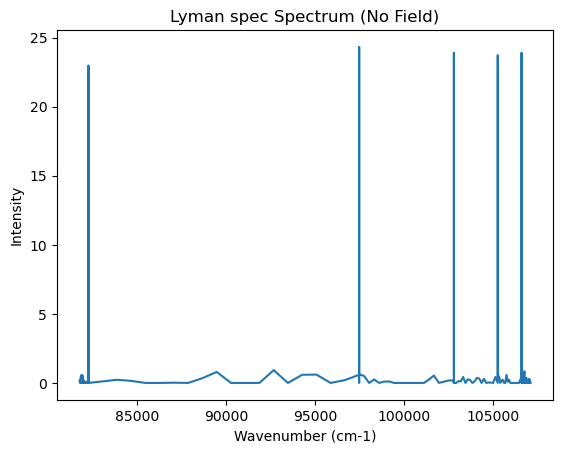

In [33]:
### SUBGOAL - load spectrum
spec = pd.read_csv('data/lyman_B0.csv')
x = spec['wavenumber_cm-1']
y = spec['intensity']
plt.plot(x, y)
plt.xlabel('Wavenumber (cm-1)')
plt.ylabel('Intensity')
plt.title('Lyman spec Spectrum (No Field)')
plt.show()

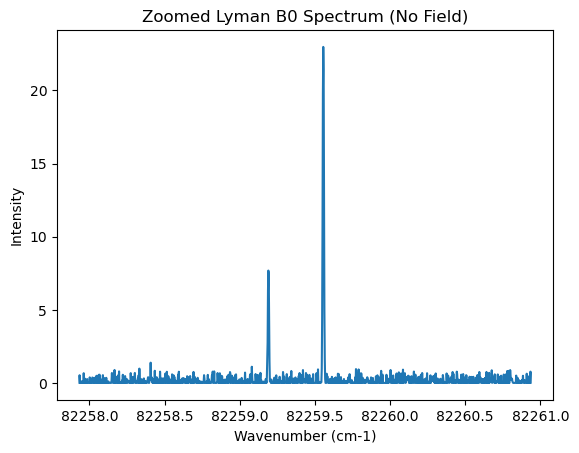

In [34]:
### Subgoal - zoom in on first peak to see fine structure
### (twiddle with numbers to get the right range)
xmax = 82258
xmin = 82261

peak1 = spec[(spec['wavenumber_cm-1'] > 82250) &(spec['wavenumber_cm-1'] < 82400)]

x = peak1['wavenumber_cm-1']
y = peak1['intensity']
plt.plot(x, y)
plt.xlabel('Wavenumber (cm-1)')
plt.ylabel('Intensity')
plt.title('Zoomed Lyman B0 Spectrum (No Field)')
plt.show()

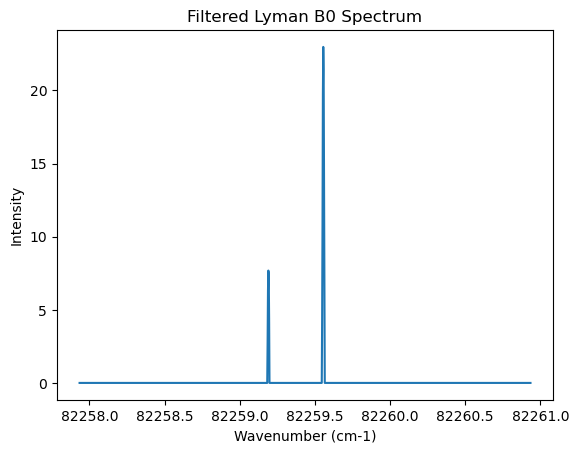

In [35]:
### Subgoal - filter out noise
noise_filter = peak1['intensity'] < peak1['intensity'].max() / 10
peak1 = peak1.copy()
peak1.loc[noise_filter, 'intensity'] = 0

x = peak1['wavenumber_cm-1']
y = peak1['intensity']
plt.plot(x, y)
plt.xlabel('Wavenumber (cm-1)')
plt.ylabel('Intensity')
plt.title('Filtered Lyman B0 Spectrum')
plt.show()

In [36]:
### Subgoal - write a reusable function to load and filter spectra
def load_spectrum(filename):
    data = pd.read_csv(f"data/{filename}")
    lyman_alpha_min = 82258.5
    lyman_alpha_max = 82260.5
    filt = (data['wavenumber_cm-1'] < lyman_alpha_max) & (data['wavenumber_cm-1'] > lyman_alpha_min)
    peak_region = data[filt].copy()
    noise_filter = peak_region['intensity'] < peak_region['intensity'].max() / 10
    peak_region.loc[noise_filter, 'intensity'] = 0
    return peak_region

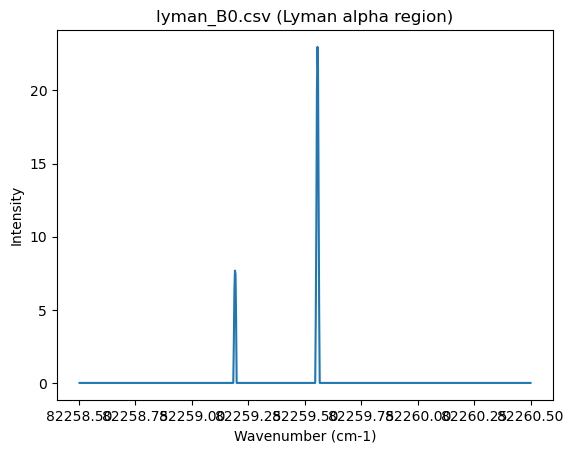

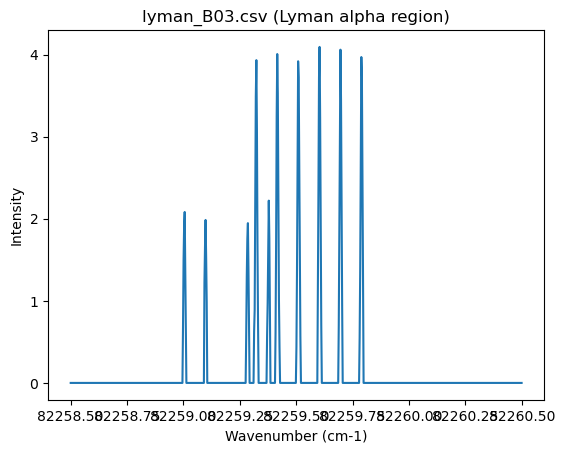

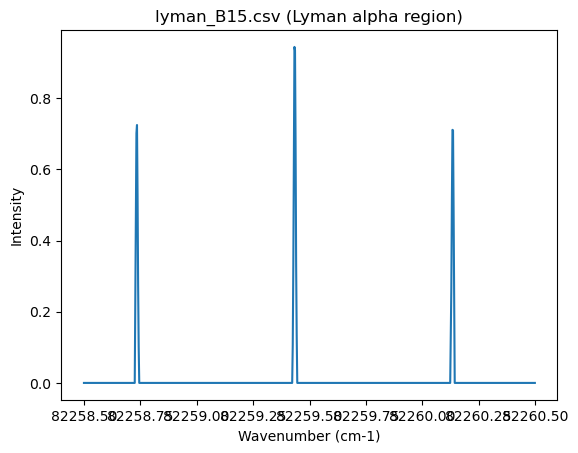

In [37]:
### Subgoal - load and view the other spectra
for fname in ["lyman_B0.csv", "lyman_B03.csv", "lyman_B15.csv"]:
    spec = load_spectrum(fname)
    x = spec['wavenumber_cm-1']
    y = spec['intensity']
    plt.plot(x, y)
    plt.xlabel('Wavenumber (cm-1)')
    plt.ylabel('Intensity')
    plt.title(f'{fname} (Lyman alpha region)')
    plt.show()

#### Part B - The Bohr Model

**The Bohr Model**

Let's use the first successful model of the H atom spectrum - the Bohr model - and see what happens as we add a magnetic perturbation.

Classically, the potential energy of an object with a magnetic dipole in a magnetic field $\vec{B}$ is given by $U = -\vec{\mu} \cdot \vec{B}$, which gives us the following expression for the energy of an electron in a magnetic field:

$$V_m = \frac{e}{2m_e}\vec{L} \cdot \vec{B}$$

A classical magnetic field exerts a torque on a magnetic dipole that causes it to align with the field. So we can assume that at equilibrium our Bohr model magnetic energy looks like:

$$V_m = \frac{\hbar e}{2m_e}B$$

The quantity $\frac{\hbar e}{2m_e}$ is known as the Bohr magneton, $\mu_B$.

**Simulating Spectra**

We want to compare this model to our spectra. This requires two mappings:

| energy levels | --> | transitions | --> | simulated spectra |

We can use this pipeline to compare our model with an experimental observable.

**Your task:**
1. Write a function for Bohr energy levels as a function of $n$ and the field strength $B$.
2. Write a function which calculates the transition energies for the Bohr model.

In [38]:
mu_B_cm_1 = 0.46686 # cm-1/T
R_H_cm_1 = 109679.25

def bohr_energy_cm_1(n, B, alpha):
    return -alpha * R_H_cm_1 / n**2 - mu_B_cm_1 * n * B

In [39]:
# generate spectrum by taking differences between energy levels
def bohr_transition_energies(B,alpha):
    E_1 = bohr_energy_cm_1(1,B,alpha) 
    transition_energies = []
    for n in range(2,6):
        E = bohr_energy_cm_1(n,B,alpha)
        E_trs = E - E_1
        transition_energies.append(E_trs)
    transition_energies = np.array(transition_energies)
    return transition_energies

--- lyman_B0.csv (B = 0 T) ---


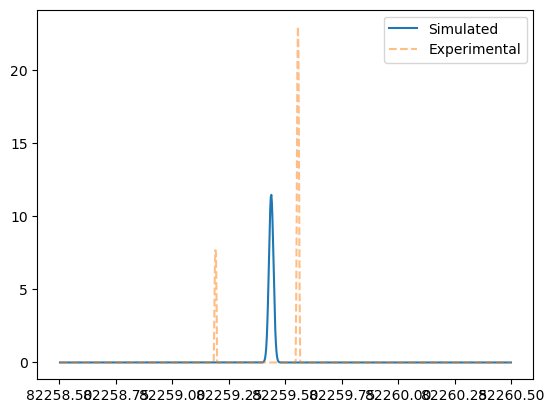

--- lyman_B03.csv (B = 0.03 T) ---


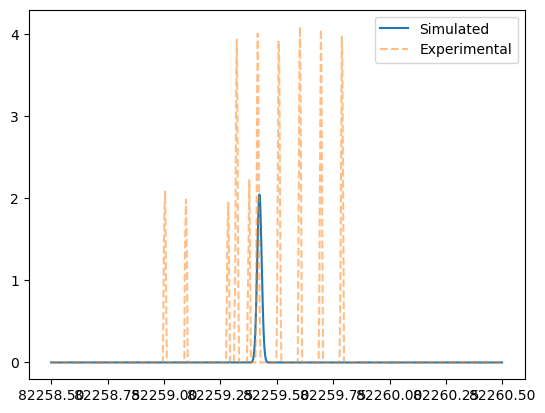

--- lyman_B15.csv (B = 1.5 T) ---


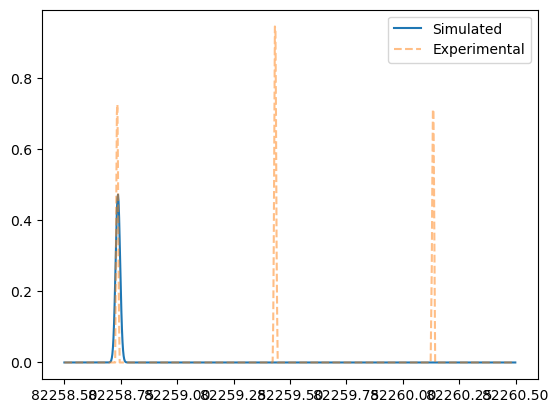

In [40]:
# Subgoal - visualize Bohr model predictions against each spectrum
for fname, B in [("lyman_B0.csv", 0), ("lyman_B03.csv", 0.03), ("lyman_B15.csv", 1.5)]:
    spec = load_spectrum(fname)
    trans = bohr_transition_energies(B, 1.0)
    print(f"--- {fname} (B = {B} T) ---")
    compare_spectra(trans, spec)

#### Part C - The Orbital Model

**The orbital model**

The Bohr model may have worked a bit questionably, but surely the H atom model you've learned in lecture will work better, right? Let's try it.

We know that the quantum number $l$ corresponds to angular momentum, and $m_l$ to the z-component of angular momentum (we take the z axis to be the direction of the magnetic field).

With that in mind, let's use $m_l$ to calculate the orbital energy splitting from the field. We'll introduce a free parameter $\alpha$ controlling the coupling strength.

We will exclusively focus on the Lyman alpha transition, since the gross structure will be the same as the Bohr model for all models. We are more interested in whether we can recover the splitting pattern.

**The energy expression**

$$E(n, l, m_l, B) = -\frac{R_H}{n^2} + \alpha \, m_l \, \mu_B \, B$$

**Your task:**
1. Write the energy function.
2. Write the transition function for $n = 2 \to n = 1$.
3. Plot the predicted transitions against the spectra with $\alpha = 1$.

In [41]:
def H_energy_level(n, l, m_l, B, alpha):
    return -R_H_cm_1 / n**2 + alpha * m_l * mu_B_cm_1 * B

In [42]:
def H_transitions(B,alpha):
    E_1 = H_energy_level(1,0,0,B,alpha)
    transitions = []
    n = 2    
    for l in range(0,n):
        for m_l in range(-l,l+1):
            E = H_energy_level(n,l,m_l,B,alpha)
            E_trs = E - E_1
            transitions.append(E_trs)
    transitions = np.array(transitions)
    return transitions

--- lyman_B0.csv (B = 0 T) ---
Transition energies: [82259.4375 82259.4375 82259.4375 82259.4375]


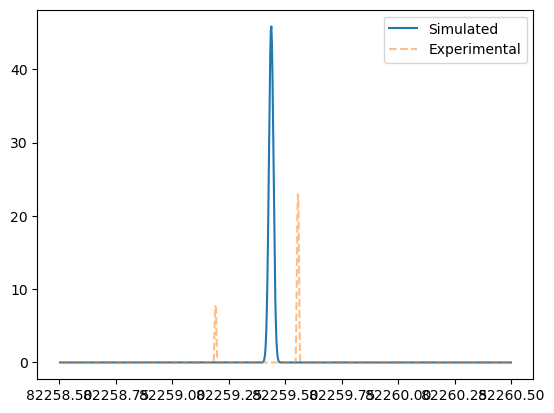

--- lyman_B03.csv (B = 0.3 T) ---
Transition energies: [82259.4375   82259.297442 82259.4375   82259.577558]


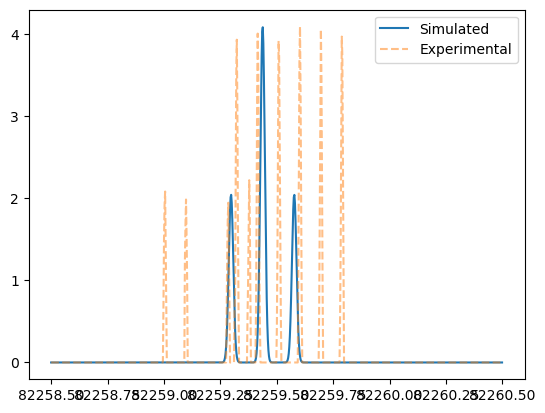

--- lyman_B15.csv (B = 1.5 T) ---
Transition energies: [82259.4375  82258.73721 82259.4375  82260.13779]


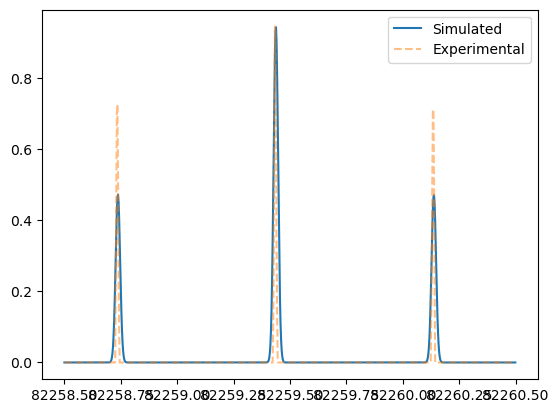

In [43]:
# Subgoal - visualize orbital model predictions with alpha = 1
for fname, B in [("lyman_B0.csv", 0), ("lyman_B03.csv", 0.3), ("lyman_B15.csv", 1.5)]:
    spec = load_spectrum(fname)
    trans = H_transitions(B, 1.0)
    print(f"--- {fname} (B = {B} T) ---")
    print("Transition energies:", trans)
    compare_spectra(trans, spec)

#### Part D - Optimization

**Optimization with a genetic algorithm**

We've been using this workflow:

| energy levels | --> | transition energies | --> | simulated spectrum |

What if you wanted to optimize parameters at the first step, based on how well the output at the third step matches the data?

This might be painful with gradient-based methods, but it's quite feasible with a non-gradient method like a genetic algorithm. We'll use `differential_evolution` from `scipy.optimize`.

The key idea: we need a function that takes our transition function as an argument and returns an objective function. This is the same "function of functions" pattern from the warmup!

**Your task:**
1. Study the provided `objective_function` wrapper.
2. Write `genetic_workflow`, which takes a transition function, bounds, field strength, and data, and returns optimized parameters.
3. Optimize both the Bohr and orbital models against the spectra.

In [44]:
# --- Worked example: wrapping a transition function into an objective function ---
from helper import spectra_overlap

def objective_function(trs_function):
    def calculate_overlap(params, fit_data, B):
        e_trs = trs_function(B, *params)
        return -spectra_overlap(e_trs, fit_data)  # negate because we minimize
    return calculate_overlap

In [45]:
from scipy.optimize import differential_evolution

def genetic_workflow(transition_function, bounds, B, fit_data, popsize=50):
    obj_func = objective_function(transition_function)
    result = differential_evolution(
        obj_func,
        bounds=bounds,
        args=(fit_data, B),
        maxiter=1000,
        popsize=popsize,
        tol=1e-3,
        mutation=(0.5, 1.5),
        seed=42
    )
    new_param = result.x
    print("optimized parameter:")
    print(new_param)

    new_trans = transition_function(B, *new_param)
    compare_spectra(new_trans, fit_data)
    print("transitions:")
    print(new_trans)
    return new_param

=== Bohr model: lyman_B0.csv (B = 0 T) ===
optimized parameter:
[1.60335706]


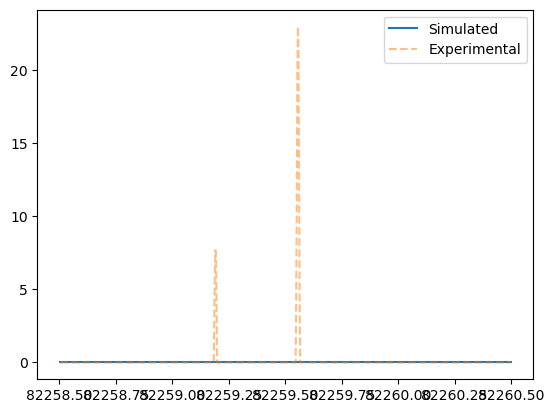

transitions:
[131891.2497694  156315.55528226 164864.06221176 168820.79970484]
=== Bohr model: lyman_B03.csv (B = 0.03 T) ===
optimized parameter:
[1.60335706]


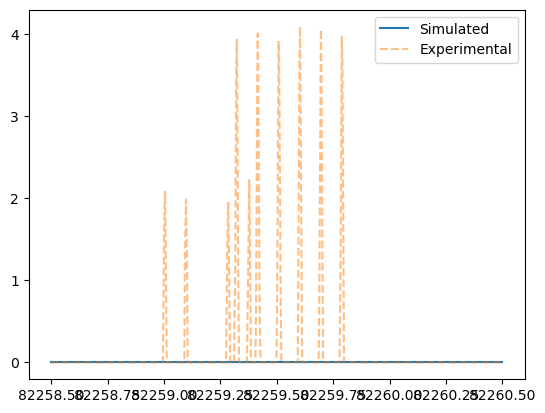

transitions:
[131891.2357636  156315.52727066 164864.02019436 168820.74368164]
=== Bohr model: lyman_B15.csv (B = 1.5 T) ===
optimized parameter:
[1.60335706]


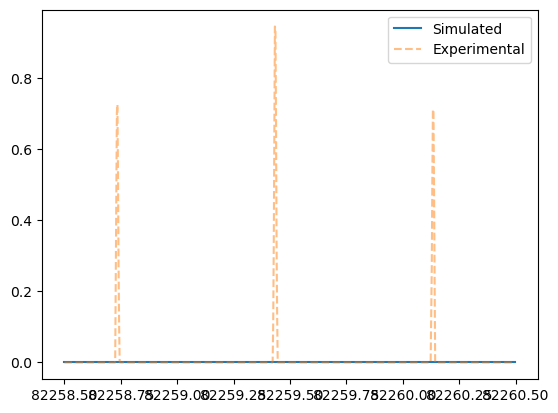

transitions:
[131890.5494794  156314.15470226 164861.96134176 168817.99854484]
=== Orbital model: lyman_B0.csv (B = 0 T) ===
optimized parameter:
[1.60335706]


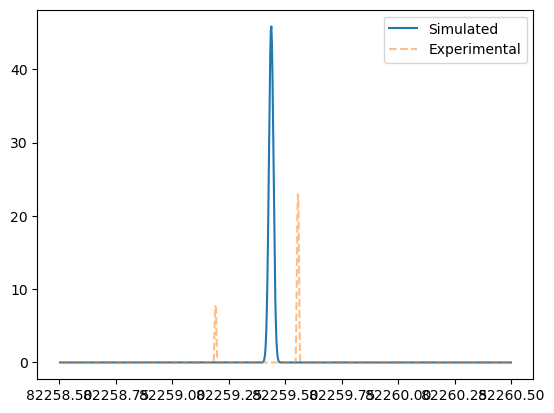

transitions:
[82259.4375 82259.4375 82259.4375 82259.4375]
=== Orbital model: lyman_B03.csv (B = 0.3 T) ===
optimized parameter:
[1.15915285]


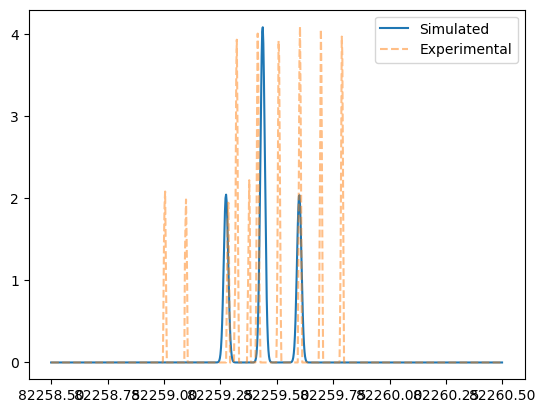

transitions:
[82259.4375     82259.27515137 82259.4375     82259.59984863]
=== Orbital model: lyman_B15.csv (B = 1.5 T) ===
optimized parameter:
[0.99970177]


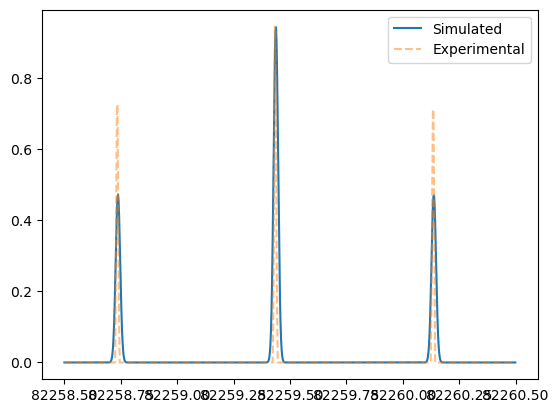

transitions:
[82259.4375     82258.73741884 82259.4375     82260.13758116]


In [46]:
# Subgoal - optimize Bohr model for each spectrum
for fname, B in [("lyman_B0.csv", 0), ("lyman_B03.csv", 0.03), ("lyman_B15.csv", 1.5)]:
    spec = load_spectrum(fname)
    print(f"=== Bohr model: {fname} (B = {B} T) ===")
    genetic_workflow(bohr_transition_energies, [(0.5, 2.0)], B, spec)

# Subgoal - optimize orbital model for each spectrum
for fname, B in [("lyman_B0.csv", 0), ("lyman_B03.csv", 0.3), ("lyman_B15.csv", 1.5)]:
    spec = load_spectrum(fname)
    print(f"=== Orbital model: {fname} (B = {B} T) ===")
    genetic_workflow(H_transitions, [(0.5, 2.0)], B, spec)

### Question 1
`10 points`

- C7.1: Understand the relationship between angular momentum and magnetism

a) How does the Bohr model's predicted spectrum change as the magnetic field increases? Does it match the experimental data?

b) The orbital model introduces $m_l$ splitting. How does the number of predicted transitions compare to what you see in the experimental spectrum? What might be missing from this model?

---

*Your answer here (`double click me!`):*

a) The Bohr model predicts a single transition energy that shifts with B, but it cannot produce the splitting pattern seen in the experimental spectra. The optimizer can match the peak position but not the fine structure.

b) The orbital model produces three transitions (from $m_l = -1, 0, +1$), which gives splitting but likely not enough peaks or the right pattern. The model is missing spin angular momentum, which doubles the number of states and changes the splitting pattern.

<br></br>

<a id="part2"></a>

## Part 2 - Spin

Our orbital model from Part 1 gave us splitting, but it probably didn't match the experimental spectra all that well. That's because we're missing something: **spin**.

Electrons have an intrinsic angular momentum called spin, with quantum number $s = 1/2$. Just like orbital angular momentum couples to a magnetic field, so does spin. The total angular momentum is described by $j$, and the z-component by $m_j$.

For a single electron, $j = l \pm 1/2$, and $m_j$ ranges from $-j$ to $+j$ in integer steps.

So for the $n = 2$ level we now have three groups of states:

| State | $l$ | $j$ | $m_j$ values |
|-------|-----|-----|-------------|
| $2s_{1/2}$ | 0 | 1/2 | $-1/2, +1/2$ |
| $2p_{1/2}$ | 1 | 1/2 | $-1/2, +1/2$ |
| $2p_{3/2}$ | 1 | 3/2 | $-3/2, -1/2, +1/2, +3/2$ |

That's a lot more transitions than we had before. Let's see if the extra complexity helps us match the data.

---

### Coding Activity 2
`10 points`

- C7.2: Explain the effect of spin and spin-orbit coupling on H atom spectra
- P7.1: Use functions of functions
- P7.2: Use a genetic algorithm for numerical optimization of complex, nonlinear functions

We'll take the same approach as Part 1 - write an energy function, enumerate transitions, and optimize against the data - but now with $j$ and $m_j$ instead of $l$ and $m_l$.

#### Part A - Adding Spin

The simplest thing we can do is swap $m_l$ for $m_j$ in our energy expression and see what happens. The energy becomes:

$$E(n, l, j, m_j, B) = -\frac{R_H}{n^2} + \beta \, m_j \, \mu_B \, B$$

where $\beta$ is a single free parameter controlling the coupling strength.

We need to enumerate all $n=2$ states (including their $j$ and $m_j$ values) and compute transitions to the $1s_{1/2}$ ground state. We'll ignore selection rules here and just include everything.

**Your task:**
1. Write the energy function using $j$ and $m_j$.
2. Write the transition function enumerating all $n=2 \to n=1$ transitions.
3. Optimize against the spectra.

In [47]:
# --- Worked example: energy function with j and m_j ---
def H_energy_spin(n, l, j, m_j, B, beta):
    return -R_H_cm_1 / n**2 + beta * m_j * mu_B_cm_1 * B

In [48]:
# Your turn: write the transition function
# Subgoal: enumerate all n=2 states and compute transitions to 1s1/2
def H_transitions_spin(B, beta):
    # ground state: 1s1/2 (l=0, j=1/2)
    E_1s = [H_energy_spin(1, 0, 0.5, m_j, B, beta) for m_j in [-0.5, 0.5]]
    transitions = []
    n = 2
    # 2s1/2 (l=0, j=1/2)
    for m_j in [-0.5, 0.5]:
        E = H_energy_spin(n, 0, 0.5, m_j, B, beta)
        for E_1 in E_1s:
            transitions.append(E - E_1)
    # 2p1/2 (l=1, j=1/2)
    for m_j in [-0.5, 0.5]:
        E = H_energy_spin(n, 1, 0.5, m_j, B, beta)
        for E_1 in E_1s:
            transitions.append(E - E_1)
    # 2p3/2 (l=1, j=3/2)
    for m_j in [-1.5, -0.5, 0.5, 1.5]:
        E = H_energy_spin(n, 1, 1.5, m_j, B, beta)
        for E_1 in E_1s:
            transitions.append(E - E_1)
    return np.array(transitions)

=== lyman_B0.csv (B = 0 T) ===
optimized parameter:
[1.60335706]


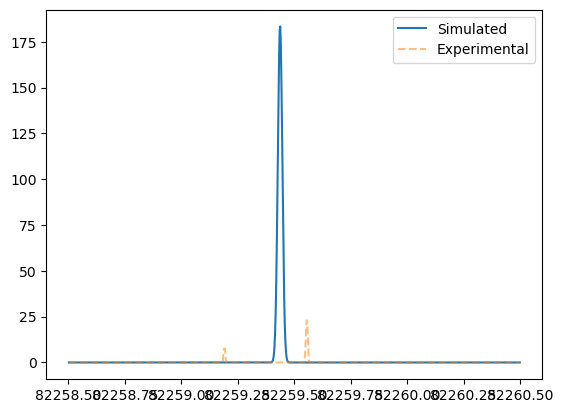

transitions:
[82259.4375 82259.4375 82259.4375 82259.4375 82259.4375 82259.4375
 82259.4375 82259.4375 82259.4375 82259.4375 82259.4375 82259.4375
 82259.4375 82259.4375 82259.4375 82259.4375]
=== lyman_B03.csv (B = 0.3 T) ===
optimized parameter:
[0.50381455]


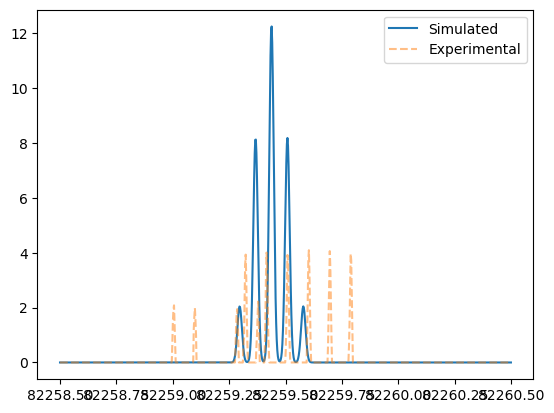

transitions:
[82259.4375     82259.36693674 82259.50806326 82259.4375
 82259.4375     82259.36693674 82259.50806326 82259.4375
 82259.36693674 82259.29637348 82259.4375     82259.36693674
 82259.50806326 82259.4375     82259.57862652 82259.50806326]
=== lyman_B15.csv (B = 1.5 T) ===
optimized parameter:
[0.99970177]


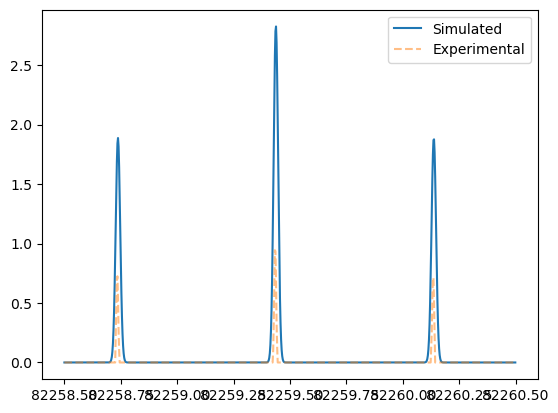

transitions:
[82259.4375     82258.73741885 82260.13758115 82259.4375
 82259.4375     82258.73741885 82260.13758115 82259.4375
 82258.73741885 82258.0373377  82259.4375     82258.73741885
 82260.13758115 82259.4375     82260.8376623  82260.13758115]


In [49]:
# Your turn: optimize against all three spectra
for fname, B in [("lyman_B0.csv", 0), ("lyman_B03.csv", 0.3), ("lyman_B15.csv", 1.5)]:
    spec = load_spectrum(fname)
    print(f"=== {fname} (B = {B} T) ===")
    genetic_workflow(H_transitions_spin, [(0.5, 2.0)], B, spec)

#### Part B - Different Coupling Strengths

A single $\beta$ for everything is a pretty blunt instrument. In reality, different states couple to the magnetic field with different strengths. When you can't make it fit, add more parameters!

We'll use three separate coupling constants:

| Parameter | States |
|-----------|--------|
| $\alpha_0$ | $1s_{1/2}$ |
| $\alpha_1$ | $2s_{1/2}$ and $2p_{1/2}$ |
| $\alpha_2$ | $2p_{3/2}$ |

Notice that we're grouping by $j$, not by $l$. States with the same $j$ get the same coupling constant.

**Your task:**
1. Write a new transition function that uses $\alpha_0$, $\alpha_1$, $\alpha_2$ for the appropriate states.
2. Optimize all three parameters against each spectrum.

In [50]:
# Your turn: transition function with separate coupling constants
def H_transitions_multi(B, alpha_0, alpha_1, alpha_2):
    # 1s1/2 ground states use alpha_0
    E_1s = [H_energy_spin(1, 0, 0.5, m_j, B, alpha_0) for m_j in [-0.5, 0.5]]
    transitions = []
    n = 2
    # 2s1/2 (j=1/2) -> alpha_1
    for m_j in [-0.5, 0.5]:
        E = H_energy_spin(n, 0, 0.5, m_j, B, alpha_1)
        for E_1 in E_1s:
            transitions.append(E - E_1)
    # 2p1/2 (j=1/2) -> alpha_1
    for m_j in [-0.5, 0.5]:
        E = H_energy_spin(n, 1, 0.5, m_j, B, alpha_1)
        for E_1 in E_1s:
            transitions.append(E - E_1)
    # 2p3/2 (j=3/2) -> alpha_2
    for m_j in [-1.5, -0.5, 0.5, 1.5]:
        E = H_energy_spin(n, 1, 1.5, m_j, B, alpha_2)
        for E_1 in E_1s:
            transitions.append(E - E_1)
    return np.array(transitions)

=== B = 0 T ===
optimized parameter:
[1.82695046 1.80758025 1.46599931]


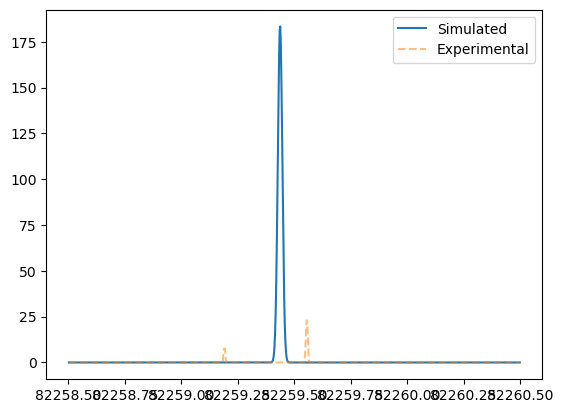

transitions:
[82259.4375 82259.4375 82259.4375 82259.4375 82259.4375 82259.4375
 82259.4375 82259.4375 82259.4375 82259.4375 82259.4375 82259.4375
 82259.4375 82259.4375 82259.4375 82259.4375]


array([1.82695046, 1.80758025, 1.46599931])

In [51]:
# Optimize with three parameters
spec = load_spectrum("lyman_B0.csv")
B = 0
bounds = [(0.5, 2.0), (0.5, 2.0), (0.5, 2.0)]
print("=== B = 0 T ===")
genetic_workflow(H_transitions_multi, bounds, B, spec)

=== lyman_B03.csv (B = 0.3 T) ===
optimized parameter:
[0.67403325 1.65134798 0.99877008]


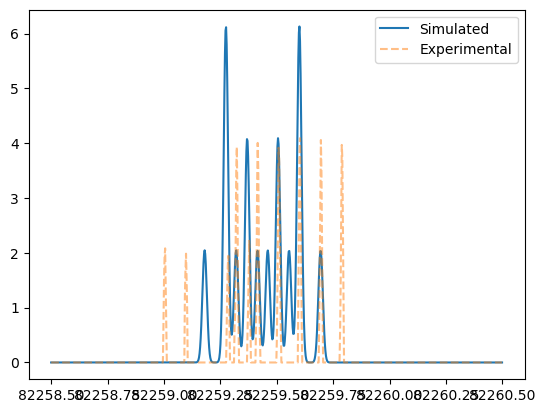

transitions:
[82259.36905963 82259.27465588 82259.60034412 82259.50594037
 82259.36905963 82259.27465588 82259.60034412 82259.50594037
 82259.27487326 82259.18046952 82259.414759   82259.32035526
 82259.55464474 82259.460241   82259.69453048 82259.60012674]
=== lyman_B15.csv (B = 1.5 T) ===
optimized parameter:
[0.99970153 0.99970246 0.99970161]


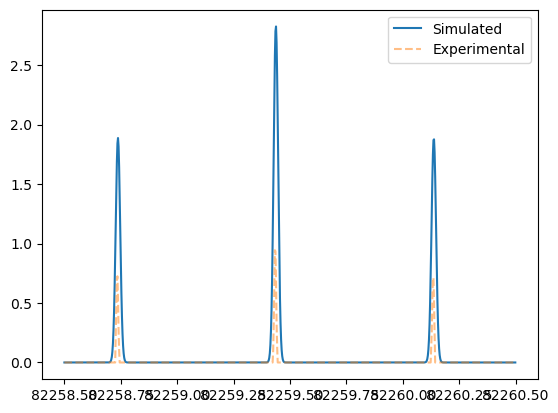

transitions:
[82259.43749968 82258.73741869 82260.13758131 82259.43750032
 82259.43749968 82258.73741869 82260.13758131 82259.43750032
 82258.73741894 82258.03733795 82259.43749998 82258.73741899
 82260.13758101 82259.43750002 82260.83766205 82260.13758106]


In [52]:
# Your turn: repeat for the other spectra
for fname, B in [("lyman_B03.csv", 0.3), ("lyman_B15.csv", 1.5)]:
    spec = load_spectrum(fname)
    bounds = [(0.5, 2.0), (0.5, 2.0), (0.5, 2.0)]
    print(f"=== {fname} (B = {B} T) ===")
    genetic_workflow(H_transitions_multi, bounds, B, spec)

#### Part C - Spin-Orbit Coupling

Adding more coupling parameters helped, but we're still missing some physics. The spin and orbital angular momenta don't just independently couple to the external field - they also couple to *each other*. This is called **spin-orbit coupling**, and it shifts the energy of states with the same $n$ but different $j$.

The spin-orbit energy correction is:

$$E_{SOC} = \frac{\alpha_{fs}^2 \, R_H}{2n^3} \cdot \frac{j(j+1) - l(l+1) - \tfrac{3}{4}}{l(l + \tfrac{1}{2})(l+1)}$$

where $\alpha_{fs} = 1/137$ is the fine structure constant. Note that this is zero when $l = 0$ (no orbital angular momentum, nothing to couple to).

We'll provide the SOC function. Your job is to write the full energy function that includes it, and a new transition function.

**Your task:**
1. Write `H_energy_soc` incorporating the provided `spin_orbit_energy` function.
2. Write a transition function using the same three-parameter scheme from Part B.
3. Optimize and compare.

In [53]:
# --- Given: spin-orbit coupling energy ---
def spin_orbit_energy(n, l, j):
    """Spin-orbit coupling correction in cm-1."""
    if l == 0:
        return 0
    alpha_fs = 1 / 137
    return (alpha_fs**2 * R_H_cm_1 / (2 * n**3)
            * (j*(j+1) - l*(l+1) - 3/4)
            / (l * (l + 0.5) * (l + 1)))

In [54]:
# Your turn: write the energy function with SOC
def H_energy_soc(n, l, j, m_j, B, alpha):
    return -R_H_cm_1 / n**2 + alpha * m_j * mu_B_cm_1 * B + spin_orbit_energy(n, l, j)

# Your turn: write the transition function (same structure as Part B)
def H_transitions_soc(B, alpha_0, alpha_1, alpha_2):
    E_1s = [H_energy_soc(1, 0, 0.5, m_j, B, alpha_0) for m_j in [-0.5, 0.5]]
    transitions = []
    n = 2
    # 2s1/2 (j=1/2) -> alpha_1
    for m_j in [-0.5, 0.5]:
        E = H_energy_soc(n, 0, 0.5, m_j, B, alpha_1)
        for E_1 in E_1s:
            transitions.append(E - E_1)
    # 2p1/2 (j=1/2) -> alpha_1
    for m_j in [-0.5, 0.5]:
        E = H_energy_soc(n, 1, 0.5, m_j, B, alpha_1)
        for E_1 in E_1s:
            transitions.append(E - E_1)
    # 2p3/2 (j=3/2) -> alpha_2
    for m_j in [-1.5, -0.5, 0.5, 1.5]:
        E = H_energy_soc(n, 1, 1.5, m_j, B, alpha_2)
        for E_1 in E_1s:
            transitions.append(E - E_1)
    return np.array(transitions)

=== SOC model: lyman_B0.csv (B = 0 T) ===
optimized parameter:
[1.80387718 1.78192428 1.39479922]


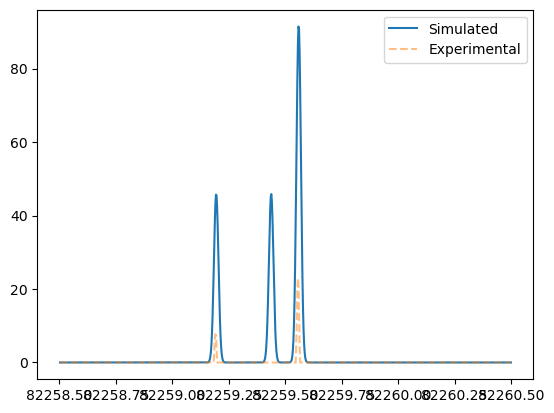

transitions:
[82259.4375     82259.4375     82259.4375     82259.4375
 82259.19401506 82259.19401506 82259.19401506 82259.19401506
 82259.55924247 82259.55924247 82259.55924247 82259.55924247
 82259.55924247 82259.55924247 82259.55924247 82259.55924247]
=== SOC model: lyman_B03.csv (B = 0.3 T) ===
optimized parameter:
[1.3224047  0.3501043  0.66142845]


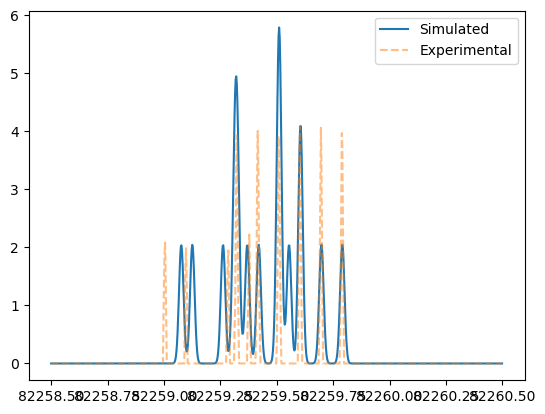

transitions:
[82259.50558922 82259.32037587 82259.55462413 82259.36941078
 82259.26210429 82259.07689093 82259.3111392  82259.12592584
 82259.51289163 82259.32767827 82259.60552997 82259.42031662
 82259.69816832 82259.51295496 82259.79080667 82259.60559331]
=== SOC model: lyman_B15.csv (B = 1.5 T) ===
optimized parameter:
[0.99938307 1.00004783 1.35981668]


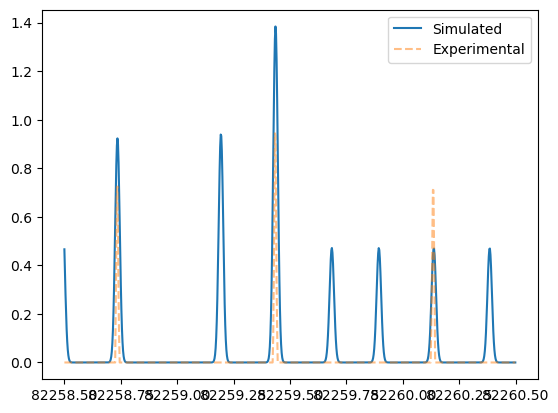

transitions:
[82259.43726724 82258.73740927 82260.13759073 82259.43773276
 82259.1937823  82258.49392433 82259.8941058  82259.19424783
 82258.48077242 82257.78091445 82259.43303844 82258.73318047
 82260.38530446 82259.68544649 82261.33757049 82260.63771252]


In [55]:
# Your turn: optimize SOC model against all three spectra
for fname, B in [("lyman_B0.csv", 0), ("lyman_B03.csv", 0.3), ("lyman_B15.csv", 1.5)]:
    spec = load_spectrum(fname)
    bounds = [(0.3, 2.0), (0.3, 2.0), (0.3, 2.0)]
    print(f"=== SOC model: {fname} (B = {B} T) ===")
    genetic_workflow(H_transitions_soc, bounds, B, spec)

### Question 2
`10 points`

- C7.2: Explain the effect of spin and spin-orbit coupling on H atom spectra

a) How did the fit change when you went from a single $\beta$ (Part A) to separate $\alpha$ parameters (Part B)? What does this tell you about how different states couple to the field?

b) Did adding spin-orbit coupling (Part C) improve the fit at zero field, at low field, or at high field? Why might SOC matter more in some regimes than others?

---

*Your answer here (`double click me!`):*

a) Allowing different coupling constants for different $j$ states should produce a noticeably better fit, especially at higher fields where the splitting pattern depends on which states shift by how much. This reflects the physical reality that states with different total angular momentum $j$ have different gyromagnetic ratios.

b) Spin-orbit coupling primarily affects the zero-field and low-field spectra, since it splits states that are otherwise degenerate (e.g., $2p_{1/2}$ vs $2p_{3/2}$). At high fields, the Zeeman splitting dominates and SOC becomes a relatively small correction.

<br></br>

<a id="part3"></a>

## Part 3 - Hund’s Rule  

#### **Competing Arrangements in Many-Electron Atoms**
In one-electron systems, the structure of the spectrum is determined entirely by the allowed eigenstates of the Hamiltonian. For many-electron atoms, this picture changes in an essential way. The Hamiltonian
$$
\hat{H} = \sum_i \left(-\frac{1}{2}\nabla_i^2 - \frac{Z}{r_i} \right) + \sum_{i<j} \frac{1}{r_{ij}}
$$
admits multiple many-electron states corresponding to the *same electron configuration*.

For partially filled shells (e.g., $2p^2$, $2p^3$), electrons can be arranged in qualitatively different ways:

- Occupying the **same orbital** or **different orbitals**  
- Forming **paired** or **aligned** spin states  

These arrangements are all consistent with the same set of orbitals and electron count, yet they represent distinct many-electron wavefunctions.

Crucially, these different arrangements reflect a balance of competing effects:

- Occupying the same orbital can lower the **one-electron energy** (if we ignore the effects of other electrons, it is lower energy to be in an orbital close to the nucleus)
- Distributing electrons across orbitals can reduce **electron-electron repulsion**  
- Different spin arrangements impose different **spatial constraints** on the electrons  

As a result, states such as a closed-shell singlet, an open-shell singlet, and a triplet can arise from the same orbital manifold, but need not have the same energy.

<div style="text-align: center;">
    <img src="https://pubs.acs.org/cms/10.1021/acs.jpca.4c02852/asset/images/medium/jp4c02852_0001.gif" width="400" style="display: block; margin: 0 auto;">
    <div style="text-align: center;">
        <em>
        Image sourced from 
        <a href="https://pubs.acs.org/doi/10.1021/acs.jpca.4c02852" target="_blank">
        Chemically Accurate Singlet-Triplet Gaps of Arylcarbenes from Local Hybrid Density Functionals by Grotjahn et al.
        </a>
        </em>
    </div>
</div>

We determine the *spin multiplicity* ('singlet', 'doublet', 'triplet', etc.) of a system using

$$
2S + 1,
$$

where $S$ is the total spin of the system. 

For example, if two electrons occupy the same orbital with opposite spins, their spins cancel and $S = 0$, giving a singlet state. Although we might label one electron as “spin up” and the other as “spin down,” exchanging the electrons does not produce a new state since electrons are indistinguishable, so there is only one distinct spin configuration.

With a single electron in a valence orbital, $S = \tfrac{1}{2}$, giving a doublet. In this case, the spin can point either up or down, corresponding to two possible spin projections.

If instead two electrons occupy *different orbitals*, their spins need not cancel. When the spins align, the total spin is

$$
S = 1,
$$

which gives a multiplicity of

$$
2S + 1 = 3.
$$

This is a **triplet state**, consisting of three possible spin projections ($M_S = +1, 0, -1$; both spins up, a symmetric combination of one spin up and one spin down, and both spins down.). These states have the same energy in the absence of a magnetic field, but they represent a fundamentally different spin structure than the singlet case.

---

#### **Energy Beyond Orbital Occupation**
The distinction between these states arises entirely from the electron-electron interaction term. Although the operator $\frac{1}{r_{ij}}$ depends only on position, the **Pauli exclusion principle** restricts the allowed wavefunctions:

- Spin determines how electrons may be distributed in space  
- Different spin arrangements therefore produce different **spatial correlations**  

This leads to a subtle but important consequence:

$$
\left\langle \sum_{i<j} \frac{1}{r_{ij}} \right\rangle
$$

depends on how electrons are arranged, not just where they can go. Thus, even when two states share the same orbital occupation, they need not share the same energy.

---

#### **From Structure to Selection**
Up to this point, our models have identified the **set of allowed states** for electrons in atoms. In many-electron systems, an additional layer emerges:

- There is not a single state associated with a configuration  
- There is a **family of competing states**, distinguished by their symmetry and spin structure  

Understanding atomic structure now requires more than listing possibilities, it requires determining how these possibilities are **ordered in energy**.

---

### Coding Activity 3
`10 points`

- C7.3: Use Psi4 to predict the ground electronic structure of atoms
- P7.3: Perform post-HF calculations in Psi4
- P7.4: Change electronic state parameters in Psi4

In previous parts, we described electronic structure by assigning electrons to orbitals and spins. In practice, this is done computationally using **multiconfigurational methods** (post-HF), which go beyond a single electron configuration.

Key ideas:
- **Hartree-Fock (HF)** uses a single Slater determinant - one configuration
- **Post-HF methods** (like CASSCF) mix multiple configurations to capture electron-electron repulsion through **correlated motion**, rather than an average field
- Different spin states (singlet, triplet) require different computational setups

#### Part A - Computing Competing Spin States with Psi4

In this part, you will use **Psi4** to compute three state energies for an atom: the closed-shell singlet, the open-shell singlet, and the triplet. For each calculation, you will need to set the appropriate spin multiplicity and SCF reference.

In [56]:
# --- Worked example: lowest singlet root (closed-shell singlet) ---

psi4.core.clean()
psi4.core.be_quiet()
psi4.set_memory("1 GB")

psi4.set_options({
    "basis": "6-31g",
    "scf_type": "pk",
    "e_convergence": 1e-8,
    "d_convergence": 1e-8,
    "reference": "rhf"
})

# Subgoal: define the atom and choose the singlet spin manifold
be_singlet = psi4.geometry("""
0 1
Be
symmetry c1
""")                                                  # YOUR COMMENT HERE (what do 0 and 1 mean?)

psi4.set_options({
    "reference": "rhf",                               # YOUR COMMENT HERE
    "restricted_docc": [1],                           # YOUR COMMENT HERE
    "active": [2],                                    # YOUR COMMENT HERE
    "num_roots": 2,                                   # YOUR COMMENT HERE
})                                                    

# Subgoal: run the CI calculation and extract the selected state energy
E_singlet, wfn_singlet = psi4.energy("casscf", molecule=be_singlet, return_wfn=True)   # YOUR COMMENT HERE

E_root0 = psi4.variable("CI ROOT 0 TOTAL ENERGY")
print(f"Closed-shell singlet energy: {E_root0:.8f} Ha")         

Closed-shell singlet energy: -14.58481184 Ha


In [57]:
# Your turn: find the energy of the open-shell singlet, remeber that it is the first configuration ("root") after the closed-shell

# YOUR CODE HERE
E_root1 = psi4.variable("CI ROOT 1 TOTAL ENERGY")
print(f"Open-shell singlet energy: {E_root1:.8f} Ha") 

Open-shell singlet energy: -14.34712826 Ha


In [58]:
psi4.core.clean()
psi4.core.be_quiet()
psi4.set_memory("1 GB")

psi4.set_options({
    "basis": "6-31g",
    "scf_type": "pk",
    "e_convergence": 1e-8,
    "d_convergence": 1e-8,
    "reference": "rohf"
})

h2_triplet = psi4.geometry("""
0 3
Be
symmetry c1
""")

E_triplet, wfn_triplet = psi4.energy("scf", molecule=h2_triplet, return_wfn=True)

print(f"Triplet energy: {E_triplet:.8f} Ha")

Triplet energy: -14.50655054 Ha


#### Part B - Automating State Energy Calculations Across Atoms

Now that you know how to compute each state for one atom, let's automate it. Write a function that computes all three state energies for a given atom, then apply it to a list of atoms.

In [59]:
# --- Worked structure: function to compute state energies for one atom ---
# Subgoal: define a function that returns [closed singlet, open singlet, triplet]

def get_state_energies(atom_symbol):
    psi4.core.clean()

    # --- Singlet calculation ---
    # Subgoal: define singlet geometry (multiplicity = 1)
    mol_singlet = psi4.geometry(f"""
    0 1
    {atom_symbol}
    symmetry c1
    """)

    _, wfn_scf = psi4.energy('scf', molecule = mol_singlet, return_wfn = True)
    restricted_docc = wfn_scf.nalpha() - 1

    # Subgoal: set options for singlet CASCI calculation
    psi4.set_options({
        "reference": "rhf",                               # YOUR COMMENT HERE
        "restricted_docc": [restricted_docc],                           # YOUR COMMENT HERE
        "active": [2],                                    # YOUR COMMENT HERE
        "num_roots": 2,                                   # YOUR COMMENT HERE
    })                                                    
    
    # Subgoal: run the singlet calculation
    E_singlet, wfn_singlet = psi4.energy("casscf", molecule=mol_singlet, return_wfn=True)   # YOUR COMMENT HERE

    # Subgoal: extract closed-shell singlet (root 0)
    # YOUR CODE HERE
    E_open = psi4.variable("CI ROOT 0 TOTAL ENERGY")

    # Subgoal: extract open-shell singlet (root 1)
    # YOUR CODE HERE
    E_closed = psi4.variable("CI ROOT 1 TOTAL ENERGY")


    # --- Triplet calculation ---
    # Subgoal: define triplet geometry (multiplicity = 3)
    mol_triplet = psi4.geometry(f"""
    0 3
    {atom_symbol}
    symmetry c1
    """)

    # Subgoal: set options for triplet calculation
    psi4.set_options({
        "basis": "6-31g",
        "scf_type": "pk",
        "e_convergence": 1e-8,
        "d_convergence": 1e-8,
        "reference": "rohf"
    })

    # Subgoal: run the triplet calculation
    # YOUR CODE HERE
    E_triplet, wfn_triplet = psi4.energy("scf", molecule=mol_triplet, return_wfn=True)

    # Subgoal: return the three energies in order
    return [E_closed, E_open, E_triplet]

In [60]:
# Your turn: apply your function to a list of atoms
# Subgoal: use the provided list of atoms and initialize a dictionary

atoms = ["Be", "Mg", "Ca"]   # provided list for this activity
state_energies = {}

# Subgoal: loop over atoms (or modify your function to handle the list directly)
for atom in atoms:
    state_energies[atom] = get_state_energies(atom)
    print(atom)
# YOUR CODE HERE

Be
Mg
Ca


In [61]:
# Your turn: inspect your results
# Subgoal: print the dictionary and verify structure

# YOUR CODE HERE
print(state_energies)

{'Be': [-14.347128263947813, -14.58481183606989, -14.506550541970356], 'Mg': [-199.38536974628903, -199.60735262721755, -199.52729421646032], 'Ca': [-676.5574436402112, -676.7175682735727, -676.6642986380384]}


#### Part C - Temperature and Spin-State Populations

In Parts A and B, you compared the **electronic energies** of different spin states. But at finite temperature, entropy also matters. Let's explore how temperature affects which spin state is favored.

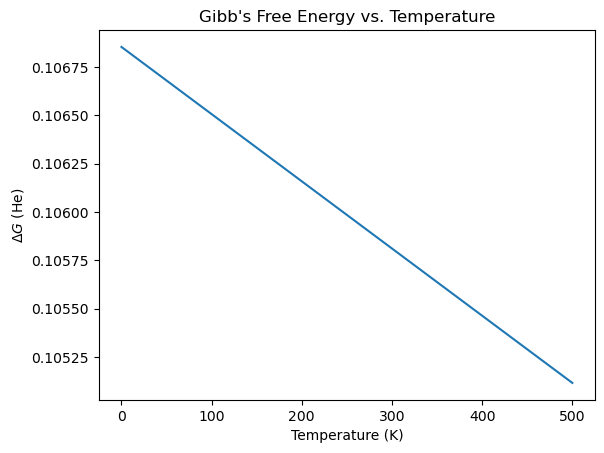

In [62]:
# --- free energy difference vs temperature ---

k_B = 3.1668114e-6  # Hartree / K

# Subgoal: extract (closed) singlet and triplet energies for carbon from your dictionary

# Hint: check the ordering you used in Part B
E_singlet = state_energies["Ca"][0]    # YOUR CODE HERE
E_triplet = state_energies["Ca"][2]    # YOUR CODE HERE

# Subgoal: compute the energy difference delta_E = E_singlet - E_triplet

delta_E = E_singlet - E_triplet  # YOUR CODE HERE


# Subgoal: define a temperature range

T = np.linspace(0, 500)   # YOUR CODE HERE


# Subgoal: compute the entropy difference using multiplicity

delta_S = k_B * np.log(3)  # YOUR CODE HERE


# Subgoal: compute the free energy difference delta_G

delta_G = delta_E - T * delta_S   # YOUR CODE HERE


# Subgoal: plot delta_G as a function of temperature

plt.plot(T, delta_G)                # YOUR CODE HERE
plt.xlabel('Temperature (K)')                  # YOUR CODE HERE
plt.ylabel(r'$\Delta G$ (He)')                  # YOUR CODE HERE
plt.title("Gibb's Free Energy vs. Temperature")                   # YOUR CODE HERE
plt.show()

In [63]:
# Your turn: estimate the crossover temperature
# Subgoal: find the temperature where delta_G changes sign

# YOUR CODE HERE
print(delta_E / delta_S)

30713.42062980284


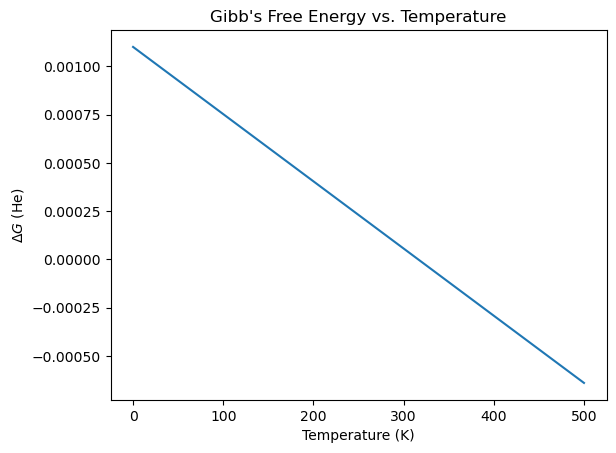

In [64]:
# Your turn: explore how changing ΔE affects the crossover
# Subgoal: modify delta_E and re-plot
delta_E = 0.0011
# YOUR CODE HERE

delta_G = delta_E - T * delta_S   # YOUR CODE HERE

plt.plot(T, delta_G)                # YOUR CODE HERE
plt.xlabel('Temperature (K)')                  # YOUR CODE HERE
plt.ylabel(r'$\Delta G$ (He)')                  # YOUR CODE HERE
plt.title("Gibb's Free Energy vs. Temperature")                   # YOUR CODE HERE
plt.show()

### Question 3
`10 points`

- C7.3: Use Psi4 to predict the ground electronic structure of atoms

a) For each atom you computed, which spin state has the lowest energy? Is this consistent with Hund's rule?

b) How does the energy gap between singlet and triplet states change across different atoms? What factors might explain this trend?

---

*Your answer here (`double click me!`):*
#### a)

For each atom, the expected qualitative ordering is:

$$
E_{\text{triplet}} < E_{\text{open-shell singlet}} < E_{\text{closed-shell singlet}}
$$

- **Triplet** is lowest in energy  
- **Open-shell singlet** is intermediate  
- **Closed-shell singlet** is highest
- 
---

#### b) 

**1. Closed-shell vs open-shell singlet (Aufbau principle)**  
- The **open-shell singlet** is lower in energy than the closed-shell singlet  
- This indicates that electrons prefer to **occupy different orbitals** rather than pair in the same orbital when possible  

**Conclusion (Aufbau-like behavior):**  
> Electrons fill degenerate orbitals by occupying separate orbitals before pairing, in order to reduce electron-electron repulsion.

---

**2. Open-shell singlet vs triplet (Hund’s rule)**  
- The **triplet** is lower in energy than the open-shell singlet  
- This indicates that electrons prefer to **align their spins** when occupying different orbitals  

**Conclusion (Hund’s rule):**  
> For a given orbital occupation, the state with the highest spin multiplicity is lowest in energy.

---

**3. Relationship between the two rules**  
- These describe **different physical effects**:

| Effect | Physical origin |
|------|---------------|
| Orbital filling (closed vs open) | electron-electron repulsion and orbital energy |
| Spin alignment (singlet vs triplet) | exchange interaction |

---

#### c)

**Combined statement:**
> Electrons in partially filled shells first occupy different orbitals to minimize electron-electron repulsion (Aufbau-like behavior), and within that distribution, they align their spins to maximize total spin (Hund’s rule), which further lowers the energy through exchange interactions.

---

**Conditions for validity:**
- Orbitals are **degenerate or nearly degenerate** (e.g., p orbitals)  
- Comparisons are made within the **same shell / orbital manifold**  
- Electron correlation effects are not dominated by other interactions  

---

**Limitations (thermodynamic considerations):**
- At finite temperature, the relevant quantity is the **free energy**:
  $$
  G = E - TS
  $$
- Higher-spin states have greater multiplicity:
  $$
  S = k_B \ln(2S+1)
  $$
- As temperature increases, **entropy can stabilize higher-multiplicity states**, even if they are higher in energy at 0 K  


<br></br>

<a id="part4"></a>

## Part 4 - Diradicals and Magnetic Coupling

In Part 3, you examined how electrons arrange themselves within a fixed set of orbitals and how competing configurations give rise to different spin states. Those systems were small enough that we could explicitly construct and compare many-electron states. 

In this part, we move to **molecular systems**, where two unpaired electrons can become spatially separated and interact through the molecular framework. These systems-**diradicals**-provide a direct setting in which spin coupling, electron correlation, and molecular structure all compete on comparable energy scales.

---

#### **Magnetic Coupling in Molecules**
A diradical contains two electrons occupying different orbitals. As in atoms, these electrons can couple to form states of different total spin:

- **Singlet state** ($S = 0$): spins paired  
- **Triplet state** ($S = 1$): spins aligned  

The relative stability of these states is characterized by the **singlet-triplet gap**:
$$
\Delta E_{ST} = E_{\text{singlet}} - E_{\text{triplet}}.
$$

This quantity reflects a balance between competing physical effects:

- **Electron delocalization** (favoring pairing in bonding orbitals)  
- **Electron-electron repulsion** (favoring spatial separation)  
- **Exchange interaction** (favoring parallel spin alignment)  

Unlike the atomic systems you studied previously, these contributions can be comparable in magnitude, so neither spin state is universally preferred. Instead, the outcome depends sensitively on the **molecular structure**.

---

#### **Diradicals as a Test of Electronic Structure Models**
Diradicals present a challenge for single-determinant methods:

- the singlet state often requires a **superposition of configurations**, since no single electron arrangement (paired or unpaired) provides a dominant description of the system
- a single determinant cannot represent this exactly  

<div style="text-align: center;">
    <img src="https://pubs.acs.org/cms/10.1021/jacs.4c13783/asset/images/large/ja4c13783_0010.jpeg" width="400" style="display: block; margin: 0 auto;">
    <div style="text-align: center;">
        <em>
        Image sourced from 
        <a href="https://pubs.acs.org/doi/10.1021/jacs.4c13783" target="_blank">
        An Acceptor-Substituted N-Heterocyclic ortho-Quinodimethane: Pushing the Boundaries of Polarization in Donor-Acceptor-Substituted Polyenes by Jama Ariai and Urs Gellrich.
        </a>
        </em>
    </div>
</div>

To approximate this behavior, we use a **broken-symmetry approach**:

- spin-up and spin-down electrons are allowed to occupy different spatial orbitals  
- the resulting state is not a pure spin eigenstate (i.e., it is not an eigenfunction of $\hat{S}^2$), but provides an estimate of the singlet energy 

This allows us to compare:
- a well-defined **triplet state**  
- an approximate **singlet state**  

and evaluate $\Delta E_{ST}$.

---

In this part, you will apply these ideas to a set of closely related organic molecules and examine how **molecular structure influences magnetic coupling**.

### Coding Activity 4
`10 points`

- C7.4: Use Psi4 to predict whether open-shell molecules are paramagnetic or diamagnetic
- P7.3: Perform post-HF calculations in Psi4
- P7.4: Change electronic state parameters in Psi4

In Part 3, you used multiconfigurational methods to explore spin states of atoms. Now we'll apply similar ideas to **diradical molecules** - molecules with two unpaired electrons that can couple through the molecular framework.

#### Part A - Building and Visualizing the Diradicals

In this part, you'll define three quinodimethane isomers (ortho, meta, para) using SMILES strings and visualize their structures.

In [65]:
# --- Worked example: define and display one diradical ---
# Subgoal: define the SMILES string for ortho-quinodimethane

oqdm = "C1=CC=CC([C]([H])[H])=C1[C]([H])[H]"

# Subgoal: display the structure to verify the geometry generation
show_molecule(oqdm)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [66]:
# Your turn: repeat for meta-quinodimethane
# Subgoal: define the SMILES string

# Subgoal: display the molecule
mqdm = "C1=CC=C([C]([H])[H])C=C1[C]([H])[H]"

show_molecule(mqdm)
# YOUR CODE HERE

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [67]:
# Your turn: repeat for para-quinodimethane
# Subgoal: define the SMILES string

# Subgoal: display the molecule
pqdm = "C1=CC([C]([H])[H])=CC=C1[C]([H])[H]"

show_molecule(pqdm)

# YOUR CODE HERE

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

#### Part B - Computing the Singlet and Triplet Energies of One Diradical

In this part, you'll compute the triplet and broken-symmetry singlet energies for ortho-quinodimethane using DFT, and calculate the singlet-triplet gap:

$$\Delta E_{ST} = E_{\text{singlet}} - E_{\text{triplet}}$$

In [68]:
# --- Worked example: triplet energy of ortho-quinodimethane ---
# Subgoal: choose method and SCF settings

psi4.set_memory("4 GB")
my_theory = "B3LYP/6-31G(d)"

psi4.set_options({
    "scf__reference": "uhf",
})

# Subgoal: build the triplet molecule and run the calculation
p4oqdm_t = create_psi4_molecule(oqdm, spin_multiplicity=3)
oqdm_t_energy, oqdm_t_wfn = psi4.energy(
    my_theory,
    return_wfn=True,
    molecule=p4oqdm_t
)

oqdm_t_energy

PSIO_ERROR: Attempt to write into next entry: 35, SO-basis Potential Energy Ints
PSIO_ERROR: unit = 35, errval = 18
PSIO_ERROR: 18 (Incorrect block end address)



RuntimeError: 
Fatal Error: PSIO_ERROR: 18 (Incorrect block end address)

Error occurred in file: /home/conda/feedstock_root/build_artifacts/psi4_1727026476030/work/psi4/src/psi4/libpsio/error.cc on line: 135
The most recent 5 function calls were:

psi::PsiException::PsiException(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >, char const*, int)
psi::PSIO::write(unsigned long, char const*, char*, unsigned long, psi::psio_address, psi::psio_address*)
psi::PSIO::write_entry(unsigned long, char const*, char*, unsigned long)
psi::Matrix::save(psi::PSIO*, unsigned long, psi::Matrix::SaveType)


In [ ]:
# Your turn: compute the broken-symmetry singlet energy of ortho-quinodimethane
# Subgoal: build the singlet molecule (multiplicity = 1)

# Subgoal: run the singlet calculation with brokensym=True

p4oqdm_s = create_psi4_molecule(oqdm, spin_multiplicity=1)
oqdm_s_energy, oqdm_s_wfn = psi4.energy(
    my_theory,
    return_wfn=True,
    molecule=p4oqdm_s
)

# YOUR CODE HERE

In [ ]:
# Your turn: compute the singlet-triplet gap for ortho-quinodimethane
# Subgoal: convert the energy difference from Hartree to kJ/mol

# Hint: 1 Hartree ≈ 2625 kJ/mol

# YOUR CODE HERE
delta_ortho = oqdm_t_energy - oqdm_s_energy
delta_ortho * 2625

23.247989026877747

#### Part C - Comparing the Singlet-Triplet Gap Across the Isomers

Now apply the same workflow to all three isomers and compare their singlet-triplet gaps. Which isomers are paramagnetic (triplet ground state) and which are diamagnetic (singlet ground state)?

In [ ]:
smiles = {
    'ortho': oqdm,
    'meta': mqdm,
    'para': pqdm
}
results = {}

for name, iso in smiles.items():
    psi4.set_memory("4 GB")
    my_theory = "B3LYP/6-31G(d)"
    
    psi4.set_options({
        "scf__reference": "uhf",
    })
    
    # Subgoal: build the triplet molecule and run the calculation
    p4_t = create_psi4_molecule(iso, spin_multiplicity=3)
    t_energy, t_wfn = psi4.energy(
        my_theory,
        return_wfn=True,
        molecule=p4oqdm_t
    )

    p4_s = create_psi4_molecule(iso, spin_multiplicity=1)
    s_energy, s_wfn = psi4.energy(
        my_theory,
        return_wfn=True,
        molecule=p4oqdm_s
    )

    
    delta = t_energy - s_energy
    results[name] = [s_energy, t_energy, delta] * 2625

results

### Question 4
`10 points`

- C7.4: Use Psi4 to predict whether open-shell molecules are paramagnetic or diamagnetic

a) From your results, report the singlet-triplet gap $\Delta E_{ST}$ for each isomer. Which are paramagnetic and which are diamagnetic?

b) Compare the three isomers and analyze how **molecular structure** affects the singlet-triplet gap. Why might the connectivity pattern between the radical centers matter?

---

*Your answer here (`double click me!`):*

#### a)

Answers may vary slightly, but a complete answer should:

- report the value of $\Delta E_{ST}$ for **ortho-, meta-, and para-quinodimethane**
- identify the lower-energy state for each isomer
- identify which isomer has the **largest magnitude** of $\Delta E_{ST}$

In general, the isomer with the largest $|\Delta E_{ST}|$ shows the **strongest magnetic coupling** between the two unpaired electrons.

---

#### b)

The three isomers differ only in the relative placement of the radical centers, so differences in $\Delta E_{ST}$ reflect differences in how effectively those radical centers interact through the molecular $\pi$ system.

A strong answer should note that:

- the **relative position** of the radicals determines how well they communicate through conjugation
- stronger communication through the $\pi$ framework leads to a larger interaction between the two unpaired electrons
- weaker communication leads to a smaller singlet-triplet gap

Chemically, this can be understood as follows:

- If the radical centers are arranged so that their orbitals interact efficiently through the conjugated framework, the coupling is stronger and $\Delta E_{ST}$ tends to have larger magnitude
- If the radical centers are arranged so that communication is weaker or less effective through the $\pi$ system, the coupling is weaker and $\Delta E_{ST}$ is smaller

Thus, the isomer with the largest $|\Delta E_{ST}|$ is the one in which the two radical centers are most effectively coupled through the molecular framework.

---

#### c) General principle and limitations

A reasonable general principle is:

> Magnetic coupling in diradicals depends strongly on how well the two radical centers communicate through the molecular framework. Greater orbital overlap or more effective $\pi$-delocalization leads to stronger coupling and a larger singlet-triplet gap, while weaker communication leads to a smaller gap.

From this, one may infer:

- a **triplet ground state** is more likely when the two unpaired electrons remain relatively separated and the molecular structure favors parallel-spin alignment
- a **singlet state** is more likely when the molecular framework allows stronger interaction, pairing, or antiferromagnetic coupling between the two radical centers

A complete answer should also discuss the computational model:

- **DFT** makes the calculation feasible for larger molecules by replacing the full interacting many-electron problem with an effective one-electron problem in terms of the density
- the **broken-symmetry singlet** is only an approximation to the true open-shell singlet
- this means the computed singlet energy is not obtained from a pure spin eigenstate

Important limitations include:

- the broken-symmetry singlet is **not an eigenfunction of $\hat{S}^2$**
- the computed $\Delta E_{ST}$ can therefore depend on the functional and the quality of the broken-symmetry solution
- DFT often captures qualitative trends well, but quantitative singlet-triplet gaps should be interpreted with caution

A strong concluding statement would be:

> These calculations are most reliable for identifying qualitative trends in how molecular structure influences magnetic coupling, rather than as exact predictions of experimental singlet-triplet gaps.

<br></br>

<a id="reflection"></a>

## Reflection
`10 points`

a) In this lab we optimized hidden models by mapping to something observable and optimizing versus a reference. Where else might this approach be useful?

b) How is the idea of abstracting patterns broadly useful outside of programming?

c) When completing this lab, what did you feel most and least confident about and why? What would have helped you feel more confident?

No right answers here, grade for engagement/effort

<br></br>